# Exercise 2: Statistical Visualization

This exercise focuses on data visualization using `matplotlib` and `seaborn`. It covers the **M3-2: Statistical Visualization** learning outcomes. We will primarily use the Palmer Penguins dataset. Work through the sections in order.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("penguins")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## A. Fundamentals of plotting

**1.** Explain the difference between a `figure` and an `axes` in `matplotlib`. (1-2 sentences)



A figure is the entire window or canvas that contains everything, while an axes is the actual plot area inside the figure where the data is drawn. One figure can contain multiple axes.



**2.** Name the three figure-level functions in `seaborn`.



sns.relplot() : for relational plots (scatter, line)


sns.displot() :for distribution plots (histogram, kde)


sns.catplot() :for categorical plots (box, bar, violin)


**3.** Briefly explain the difference between a **Histogram** and a **Barplot**. Which one is used to show the distribution of numerical data, and which is used for categorical data?



A Histogram is used to show the distribution of numerical data by grouping values into bins (e.g. distribution of body mass). A Barplot is used for categorical data to show the count or mean of each category (e.g. average body mass per species).


## B. Subplots and Grids

**1.** Using a seaborn **figure-level** function (like `sns.relplot` or `sns.displot`), create subplots using the `col` and `row` parameters. For example, plot `flipper_length_mm` vs `body_mass_g` across columns for `sex` and rows for `island`.

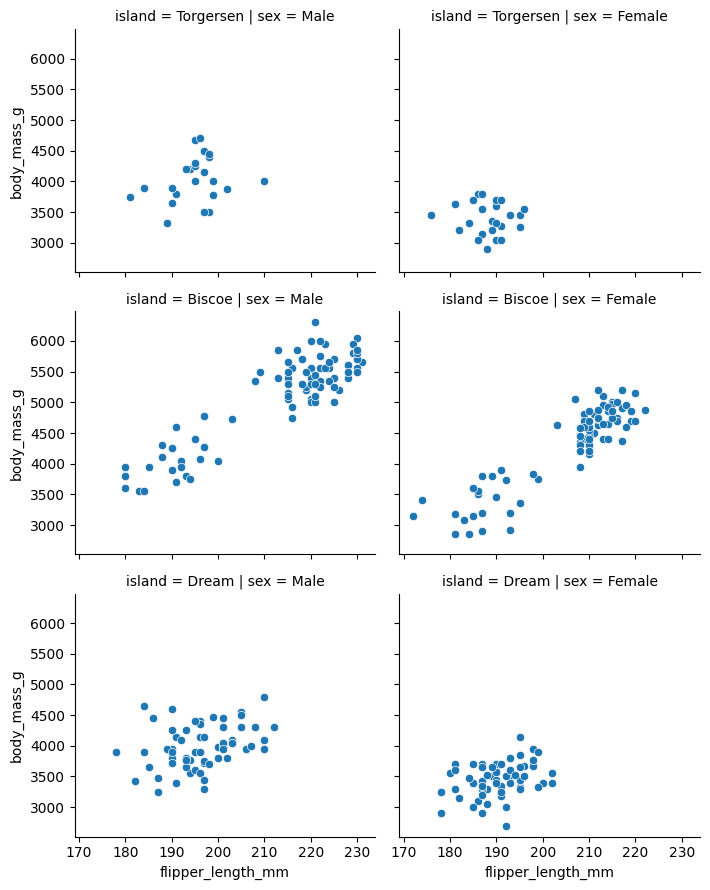

In [2]:
sns.relplot(
    data=df,
    x='flipper_length_mm',
    y='body_mass_g',
    col='sex',
    row='island',
    height=3,
    aspect=1.2
)
plt.show()

**2.** Using **axes-level** functions, create a figure with subplots (e.g., 1 row and 2 columns) using `plt.subplots`. 
- Plot a scatterplot of `bill_length_mm` vs `bill_depth_mm` on the first axes (`ax1`).
- Plot a boxplot (or another axes-level plot of your choice) of `bill_length_mm` by `species` on the second axes (`ax2`).
- Make sure to use `sharey=True` (or `sharex=True`) where appropriate so the subplots are linked on the shared dimension.

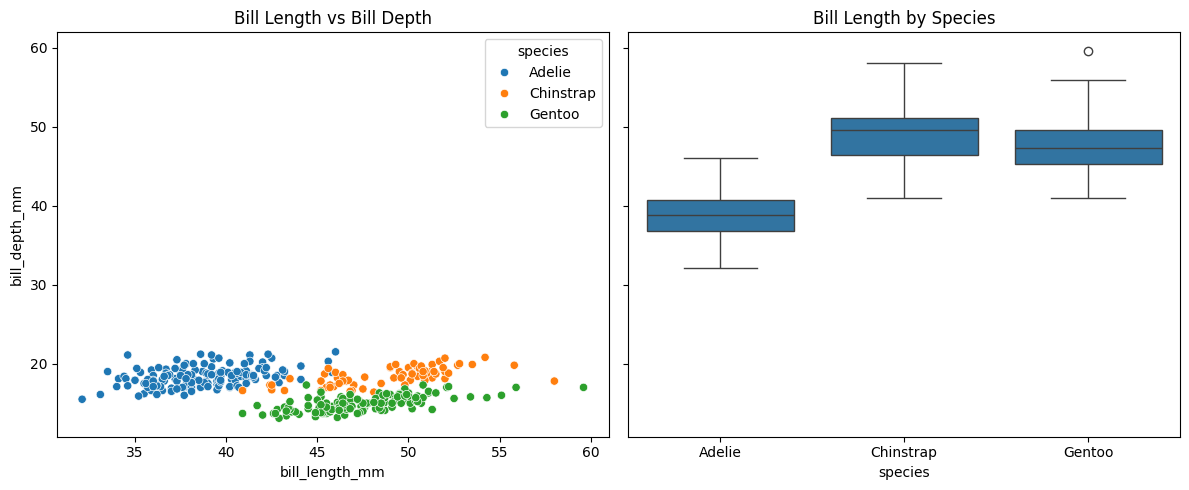

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# First axes — scatterplot
sns.scatterplot(
    data=df,
    x='bill_length_mm',
    y='bill_depth_mm',
    hue='species',
    ax=ax1
)
ax1.set_title('Bill Length vs Bill Depth')

# Second axes — boxplot
sns.boxplot(
    data=df,
    x='species',
    y='bill_length_mm',
    ax=ax2
)
ax2.set_title('Bill Length by Species')

plt.tight_layout()
plt.show()

## C. Visualizing Distributions

**1.** Write code to show a **box plot** of `flipper_length_mm` separated by `species`.

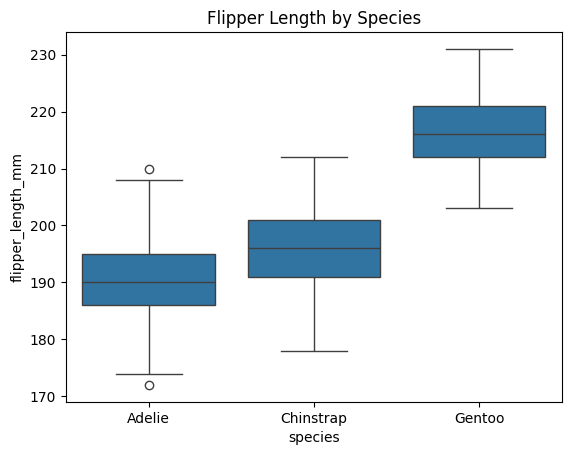

In [4]:
sns.boxplot(data=df, x='species', y='flipper_length_mm')
plt.title('Flipper Length by Species')
plt.show()



**2.** Show two distributions on the same figure axes: plot the distribution of `body_mass_g` grouped by `sex` (e.g., using `sns.kdeplot`, or `sns.histplot` with overlapping transparent bins).



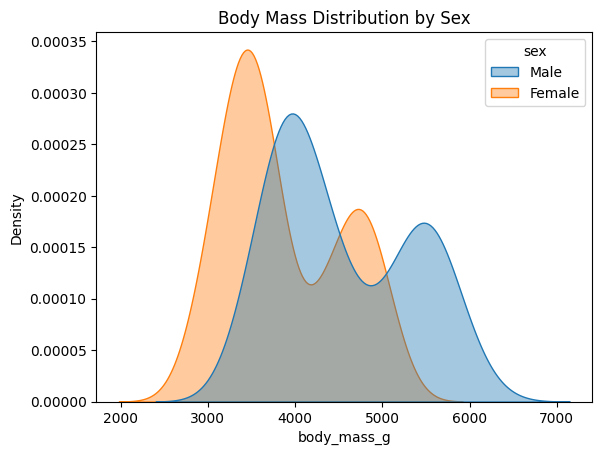

In [5]:
sns.kdeplot(data=df, x='body_mass_g', hue='sex', fill=True, alpha=0.4)
plt.title('Body Mass Distribution by Sex')
plt.show()



**3.** Plot the Empirical Cumulative Distribution Function (**ECDF**) for `body_mass_g`, split by `species`. Briefly interpret what the plot tells you about how the species compare in weight.



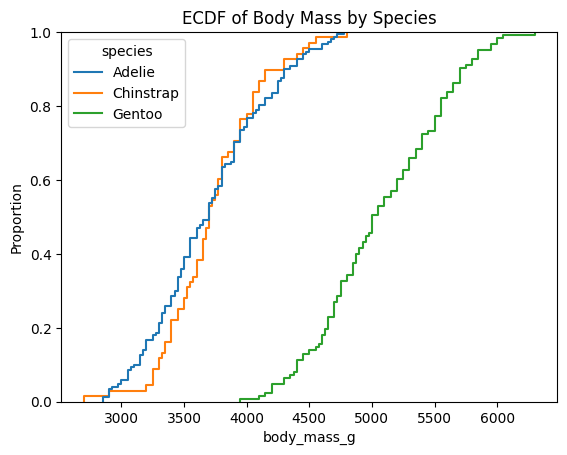

In [6]:
sns.ecdfplot(data=df, x='body_mass_g', hue='species')
plt.title('ECDF of Body Mass by Species')
plt.show()



The ECDF plot shows that Gentoo penguins are clearly the heaviest — their curve is shifted far to the right compared to Adelie and Chinstrap. Adelie and Chinstrap have very similar weight distributions, with most of their values falling between 3000g and 4500g, while most Gentoo penguins weigh between 4500g and 6000g.


**4.** Plot a **bi-variate histogram** using `sns.histplot` showing `bill_length_mm` on the x-axis and `bill_depth_mm` on the y-axis. What does the intensity mapping (the color blocks) represent?



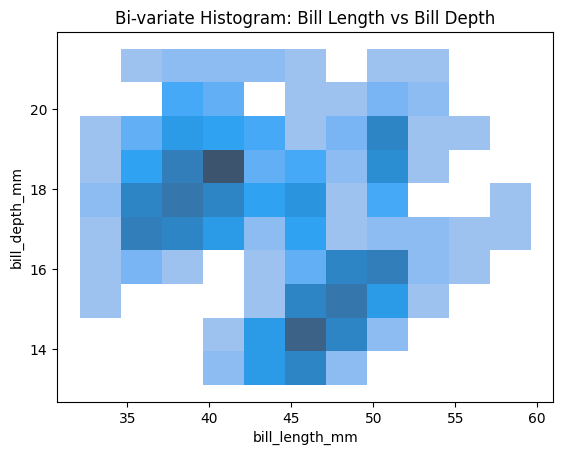

In [7]:
sns.histplot(data=df, x='bill_length_mm', y='bill_depth_mm')
plt.title('Bi-variate Histogram: Bill Length vs Bill Depth')
plt.show()



The color intensity (darker = more penguins) represents the count of penguins that fall within each rectangular bin. The darker the block, the more penguins have that combination of bill length and bill depth. Lighter or empty blocks mean very few or no penguins have that combination.


## D. Categorical Data

**1.** Visualize numerical vs categorical relationships using `sns.catplot()`. Plot `bill_depth_mm` across different `island`s. Experiment with different categorical plot kinds (e.g., `kind='violin'` or `kind='swarm'`).

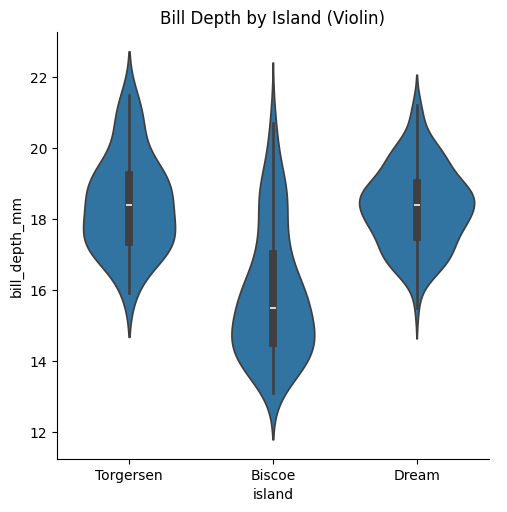

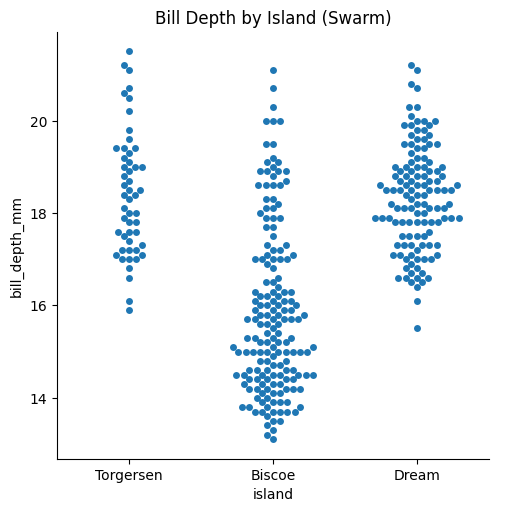

In [8]:
# Violin plot
sns.catplot(data=df, x='island', y='bill_depth_mm', kind='violin')
plt.title('Bill Depth by Island (Violin)')
plt.show()

# Swarm plot
sns.catplot(data=df, x='island', y='bill_depth_mm', kind='swarm')
plt.title('Bill Depth by Island (Swarm)')
plt.show()

**2.** Visualize multiple categorical variables in one plot. Show a count of penguins by `island`, and further separate the counts by `species` (using the `hue` parameter in a count plot or a similar approach).

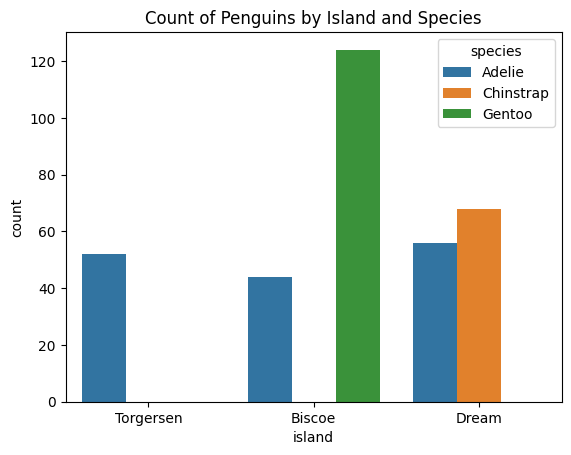

In [9]:
sns.countplot(data=df, x='island', hue='species')
plt.title('Count of Penguins by Island and Species')
plt.show()

## E. Relational Plots and Aesthetics

**1.** Relate two numerical variables using a simple **scatter plot**: plot `bill_length_mm` vs `flipper_length_mm`.

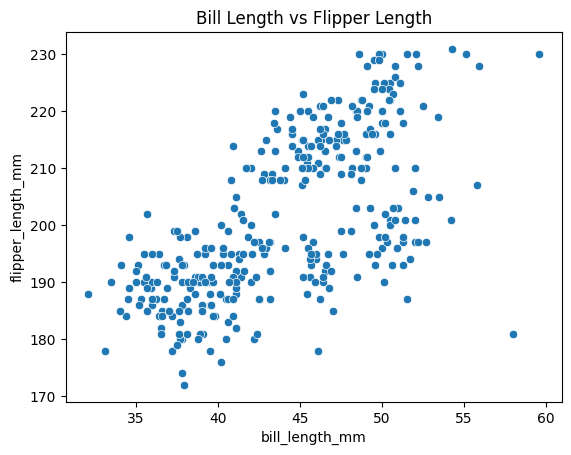

In [10]:
sns.scatterplot(data=df, x='bill_length_mm', y='flipper_length_mm')
plt.title('Bill Length vs Flipper Length')
plt.show()

**2.** Enhance the scatter plot from the previous step by using different **colors** (`hue`), **markers** (`style`), and **sizes** (`size`) based on other variables in the dataset. Make the plot visually distinct and ensure it is readable.

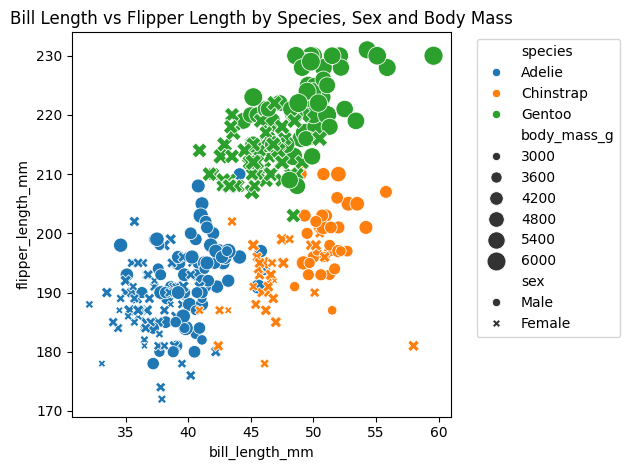

In [11]:
sns.scatterplot(
    data=df,
    x='bill_length_mm',
    y='flipper_length_mm',
    hue='species',       # color by species
    style='sex',         # marker shape by sex
    size='body_mass_g',  # size by body mass
    sizes=(20, 200)      # min and max size
)
plt.title('Bill Length vs Flipper Length by Species, Sex and Body Mass')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()